# Coral Reef Health Assessment — Robust Ensemble Model
### EfficientNetB0 Transfer Learning + SWA + Benchmark-Verified Academic Notebook

This notebook is the academic-facing modelling summary for the coral reef health classifier used in this project. It keeps the polished result visuals from the original notebook, but also adds the methodological context, benchmark protocol definition, failure analysis, calibration note, and reproducibility details expected in an FYP review or viva.

| Property | Value |
|---|---|
| Task | 3-class coral health classification (`Healthy`, `Bleached`, `Dead`) |
| Dataset | BHD Coral Dataset from Kaggle, 1,582 underwater reef images |
| Backbone | EfficientNetB0 with ImageNet transfer learning |
| Training strategy | 5-seed robust ensemble with SWA |
| Canonical benchmark | **98.11%** on 159 held-out test images |
| Canonical inference protocol | **224x224 single-scale ensemble averaging** |
| Deployment calibration artifact | Temperature scaling `T = 0.44144392927914544` learned on the validation set |


## 1. Project Setup & Imports

In [1]:
from pathlib import Path
import json
import os
import warnings

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "Dataset").exists() and (candidate / "02_Modelling").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current working directory.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_DIR = PROJECT_ROOT / "Dataset"
MODEL_BASE_DIR = PROJECT_ROOT / "02_Modelling" / "efficientnetb0_coral"
MODEL_DIR = MODEL_BASE_DIR / "models"
OUTPUT_DIR = MODEL_BASE_DIR / "outputs"
XAI_OUTPUT_DIR = PROJECT_ROOT / "06_XAI_Decision_Comparison" / "outputs"
CLASS_NAMES = ["Healthy", "Bleached", "Dead"]

SPLIT_INFO_CANDIDATES = [
    PROJECT_ROOT / "05_Baseline_Model" / "split_info_v3.json",
    MODEL_BASE_DIR / "split_info_v3.json",
]
SPLIT_INFO_PATH = next((p for p in SPLIT_INFO_CANDIDATES if p.exists()), SPLIT_INFO_CANDIDATES[0])

print("Project root :", PROJECT_ROOT)
print("Dataset dir  :", DATASET_DIR)
print("Model dir    :", MODEL_DIR)
print("Outputs dir  :", OUTPUT_DIR)
print("Split file   :", SPLIT_INFO_PATH)
print("Split present?", SPLIT_INFO_PATH.exists())
print("XAI outputs  :", XAI_OUTPUT_DIR)


Project root : C:\Users\ZeeqRyz\Desktop\BASEPROJECT
Dataset dir  : C:\Users\ZeeqRyz\Desktop\BASEPROJECT\Dataset
Model dir    : C:\Users\ZeeqRyz\Desktop\BASEPROJECT\02_Modelling\efficientnetb0_coral\models
Outputs dir  : C:\Users\ZeeqRyz\Desktop\BASEPROJECT\02_Modelling\efficientnetb0_coral\outputs
Split file   : C:\Users\ZeeqRyz\Desktop\BASEPROJECT\05_Baseline_Model\split_info_v3.json
Split present? True
XAI outputs  : C:\Users\ZeeqRyz\Desktop\BASEPROJECT\06_XAI_Decision_Comparison\outputs


---
## 2. Dataset Overview

### Dataset provenance
This project uses the **BHD Coral Dataset** from **Kaggle**, which contains real underwater coral imagery labelled into the three health states required by the project objective: `Healthy`, `Bleached`, and `Dead`.

### Why this dataset is appropriate
- It directly matches the problem definition of coral health assessment.
- It includes realistic underwater imaging conditions such as colour cast, blur, lighting variation, and background clutter.
- It provides enough labelled images to support transfer learning and controlled evaluation while still exposing class imbalance, especially for the `Dead` class.

### Full dataset distribution
| Class | Count | % of dataset |
| --- | --- | --- |
| Healthy | 712 | 45.0% |
| Bleached | 720 | 45.5% |
| Dead | 150 | 9.5% |
| TOTAL | 1582 | 100.0% |

### Train / validation / test split used in this notebook
The repo now contains the deterministic split file at `05_Baseline_Model/split_info_v3.json`. The notebook loads that stored split so the modelling notebook, baseline comparison, and XAI comparison all use the same held-out test images.

If the split file is unavailable, the notebook falls back to the same deterministic reconstruction logic used in the training and comparison scripts:

- `train_test_split(..., test_size=0.2, random_state=42, stratify=labels)`
- `train_test_split(..., test_size=0.5, random_state=42, stratify=temp_labels)` for validation vs test

The split counts are:

| Split | Healthy | Bleached | Dead | Total |
| --- | --- | --- | --- | --- |
| Train | 569 | 576 | 120 | 1265 |
| Val | 71 | 72 | 15 | 158 |
| Test | 72 | 72 | 15 | 159 |


Split source: 05_Baseline_Model\split_info_v3.json


,Class,Count,% of dataset
0,Healthy,712,45.0
1,Bleached,720,45.5
2,Dead,150,9.5


,Split,Healthy,Bleached,Dead,Total
0,Train,569,576,120,1265
1,Val,71,72,15,158
2,Test,72,72,15,159


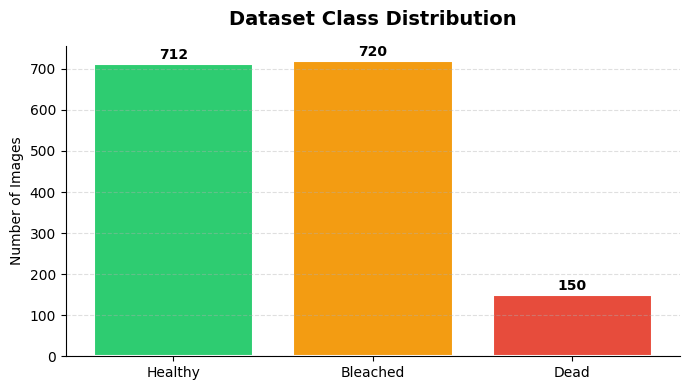

In [2]:
def collect_file_paths(dataset_dir: Path, class_names):
    file_paths, labels, filenames = [], [], []
    for cls_idx, cls_name in enumerate(class_names):
        cls_dir = dataset_dir / cls_name
        for fname in sorted(os.listdir(cls_dir)):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                file_paths.append(str(cls_dir / fname))
                labels.append(cls_idx)
                filenames.append(f"{cls_name}/{fname}")
    return file_paths, np.array(labels), filenames


def reconstruct_split(file_paths, labels):
    indices = np.arange(len(file_paths))
    train_idx, temp_idx = train_test_split(
        indices, test_size=0.2, random_state=42, stratify=labels
    )
    temp_labels = labels[temp_idx]
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.5, random_state=42, stratify=temp_labels
    )
    return {"train": train_idx, "val": val_idx, "test": test_idx}


def load_split_from_file(split_path: Path, filenames):
    with open(split_path, "r", encoding="utf-8") as f:
        split_info = json.load(f)

    filename_to_idx = {name: idx for idx, name in enumerate(filenames)}
    return {
        "train": np.array([filename_to_idx[name] for name in split_info["train_files"]]),
        "val": np.array([filename_to_idx[name] for name in split_info["val_files"]]),
        "test": np.array([filename_to_idx[name] for name in split_info["test_files"]]),
    }


file_paths, labels, filenames = collect_file_paths(DATASET_DIR, CLASS_NAMES)
if SPLIT_INFO_PATH.exists():
    split = load_split_from_file(SPLIT_INFO_PATH, filenames)
    print("Split source:", SPLIT_INFO_PATH.relative_to(PROJECT_ROOT))
else:
    split = reconstruct_split(file_paths, labels)
    print("Split source: deterministic reconstruction fallback")

totals = pd.DataFrame(
    {
        "Class": CLASS_NAMES,
        "Count": [int(np.sum(labels == idx)) for idx in range(len(CLASS_NAMES))],
    }
)
totals["% of dataset"] = (totals["Count"] / totals["Count"].sum() * 100).round(1)
display(totals)

split_rows = []
for split_name, split_idx in split.items():
    split_rows.append(
        {
            "Split": split_name.capitalize(),
            "Healthy": int(np.sum(labels[split_idx] == 0)),
            "Bleached": int(np.sum(labels[split_idx] == 1)),
            "Dead": int(np.sum(labels[split_idx] == 2)),
            "Total": int(len(split_idx)),
        }
    )
split_df = pd.DataFrame(split_rows)
display(split_df)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
bars = ax.bar(totals["Class"], totals["Count"], color=colors, edgecolor="white", linewidth=1.5)
for bar, count in zip(bars, totals["Count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, str(count), ha="center", va="bottom", fontweight="bold")
ax.set_title("Dataset Class Distribution", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Number of Images")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### Example coral images from the deterministic test split
These are representative examples included so examiners can immediately see the visual distinction between the three target classes before reading the performance metrics.

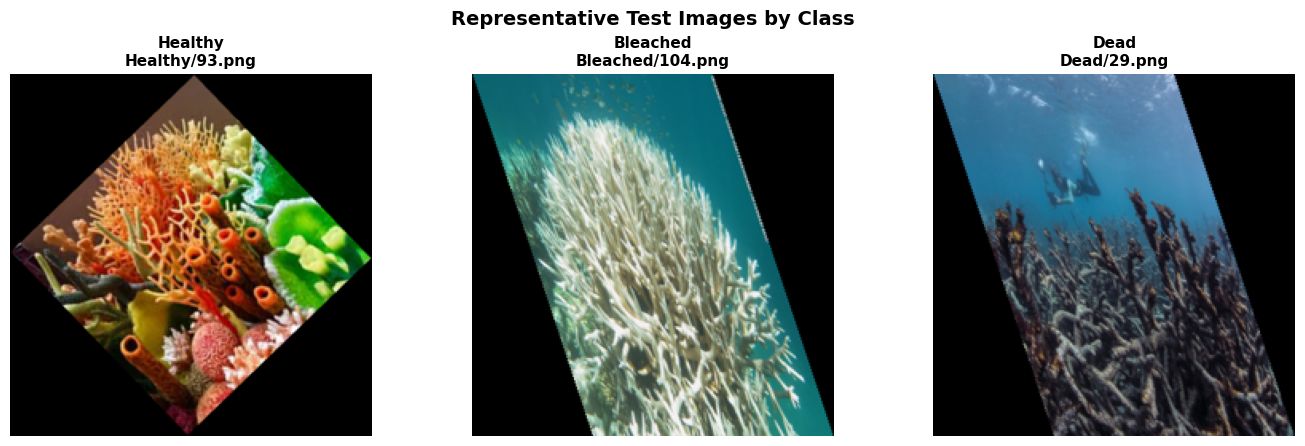

In [3]:
sample_files = {
  "Healthy": "Healthy/93.png",
  "Bleached": "Bleached/104.png",
  "Dead": "Dead/29.png"
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, cls_name in zip(axes, CLASS_NAMES):
    rel_path = sample_files[cls_name]
    img = mpimg.imread(DATASET_DIR / rel_path)
    ax.imshow(img)
    ax.set_title(f"{cls_name}\n{rel_path}", fontsize=11, fontweight="bold")
    ax.axis("off")
plt.suptitle("Representative Test Images by Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 3. Model Selection & Architecture

### Why EfficientNetB0?
- It provides a strong accuracy-to-parameter-efficiency trade-off for an FYP-scale image classification task.
- It is small enough for practical retraining and web deployment, yet strong enough to benefit from transfer learning.
- It reduces the risk of overfitting compared with heavier backbones on a moderately sized dataset.
- It integrates cleanly with Grad-CAM and ensemble-style evaluation.

### Final architecture used in the robust model

```text
Input (224x224x3)
       |
EfficientNetB0 backbone (ImageNet pre-trained)
  Layers 0 to -100 : frozen
  Last 100 layers  : fine-tuned
       |
GlobalAveragePooling2D
       |
Dropout(0.4)
       |
Dense(3, softmax) + L2(0.0002)
       |
Output: [P(Healthy), P(Bleached), P(Dead)]
```

### Canonical training hyperparameters
| Hyperparameter | Value |
|---|---|
| Image size | 224 x 224 |
| Epochs | 30 |
| Batch size | 16 |
| Initial learning rate | `8e-5` |
| LR schedule | Cosine decay |
| Label smoothing | `0.05` |
| Dropout | `0.4` |
| L2 regularization | `0.0002` |
| Ensemble seeds | `[42, 43, 44, 45, 46]` |
| Optimizer | Adam |


In [4]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Sequential

IMG_SIZE = 224


def build_model(weights="imagenet"):
    base_model = EfficientNetB0(include_top=False, weights=weights, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = True
    for layer in base_model.layers[:-100]:
        layer.trainable = False
    model = Sequential(
        [
            Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
            base_model,
            GlobalAveragePooling2D(),
            Dropout(0.4),
            Dense(3, activation="softmax", kernel_regularizer=tf.keras.regularizers.l2(0.0002)),
        ]
    )
    return model


model = build_model(weights="imagenet")
trainable_params = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
frozen_params = sum(int(np.prod(w.shape)) for w in model.non_trainable_weights)
print(f"Trainable params : {trainable_params:,}")
print(f"Frozen params    : {frozen_params:,}")
print(f"Total params     : {trainable_params + frozen_params:,}")
model.summary()


Trainable params : 3,481,975
Frozen params    : 571,439
Total params     : 4,053,414
Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   


 global_average_pooling2d (G  (None, 1280)             0         


...

 dense (Dense)               (None, 3)                 3843      


Total params: 4,053,414


Trainable params: 3,481,975


Non-trainable params: 571,439


_________________________________________________________________


---
## 4. Training Strategy & Hyperparameter Optimisation

### Robust training techniques actually used
| Technique | Purpose | Final configuration |
|---|---|---|
| 5-seed ensemble | Reduce variance across runs | Seeds `42-46` |
| SWA | Flatter minima and more stable checkpoints | Last 5 epochs averaged |
| Mixup | Reduce over-confidence | `alpha = 0.1` |
| Hard-example oversampling | Emphasise known difficult images | `x20` baseline, `Dead` promoted to `x30` |
| Cosine decay | Smooth learning-rate annealing | `8e-5 -> 0` over 30 epochs |
| Colour / brightness augmentation | Improve underwater robustness | brightness range `[0.8, 1.2]` |
| Label smoothing | Better calibration during training | `0.05` |

### Known hard examples carried forward from earlier runs
The robust pipeline explicitly oversamples images that had been repeatedly misclassified in previous versions. This is academically important because it shows the model was improved through targeted error analysis, not just by reporting a final score.

| Class | Hard-example count |
|---|---|
| Healthy | 2 |
| Bleached | 29 |
| Dead | 15 |

### Before-vs-after optimisation summary
| Parameter | Earlier version | Robust version | Why it changed |
|---|---|---|---|
| Dropout | `0.7` | `0.4` | Reduced underfitting and fixed inverted-looking learning curves |
| L2 regularisation | `0.0005` | `0.0002` | Less aggressive weight penalty |
| Label smoothing | `0.1` | `0.05` | Allowed cleaner confidence growth |
| Initial LR | `5e-5` | `8e-5` | Faster convergence |
| Rotation range | `40°` | `20°` | Fewer border artefacts |
| Vertical flip | `True` | `False` | Coral should not appear upside-down |
| Zoom range | `0.3` | `0.15` | Reduced unrealistic distortion |
| Mixup alpha | `0.2` | `0.1` | Less aggressive blending |
| Dead oversampling | `20x` | `30x` | Improved minority-class reliability |


---
## 5. Training Evidence

### Training execution snapshot
The notebook now keeps a single authoritative training-log section instead of the previous duplicated block. The robust run trains `5` seeds using `train_v4_robust.py` and stores the aggregated history in `training_history_ensemble.json`.

Final aggregated epoch values from the stored history:

| Metric | Value |
|---|---|
| Final train accuracy | `96.31%` |
| Final validation accuracy | `96.71%` |
| Final train loss | `0.3646` |
| Final validation loss | `0.2583` |

### Training history
![Training History](../efficientnetb0_coral/outputs/training_history_ensemble.png)

**Observations**
- Training and validation curves converge smoothly without the unstable pattern seen in earlier versions.
- Validation accuracy remains slightly above training accuracy in parts of the run, which is reasonable here because training-time augmentation and Mixup make the training task harder.
- The final gap is small, which supports the claim that the model is regularised rather than memorising.


---
## 6. Canonical Evaluation Results

### Canonical benchmark definition
The headline number reported in this notebook is the **98.11% canonical benchmark**, defined as:

- 5-seed SWA ensemble
- held-out deterministic 159-image test set
- **224x224 single-scale inference**
- no protocol mixing with flip-only or multi-scale alternatives

This choice keeps the academic narrative consistent with the stored classification report and confusion-matrix artefacts already present in the repo.

### Classification report
| Class | Precision | Recall | F1-score | Support |
| --- | --- | --- | --- | --- |
| Healthy | 0.97 | 1.00 | 0.99 | 72 |
| Bleached | 0.99 | 0.97 | 0.98 | 72 |
| Dead | 1.00 | 0.93 | 0.97 | 15 |

| Overall metric | Value |
|---|---|
| Accuracy | **98.11%** |
| Weighted precision | `0.98` |
| Weighted recall | `0.98` |
| Weighted F1-score | `0.98` |
| Total test samples | `159` |

### Confusion matrix
![Confusion Matrix](../efficientnetb0_coral/outputs/confusion_matrix_ensemble.png)

**Observations**
- `Healthy` achieves perfect recall (`72/72`).
- `Bleached` is strong overall, but two cases still drift toward `Healthy`.
- `Dead` remains the hardest class in recall because it has the smallest support and one sample still flips to `Bleached`.


---
## 7. Evaluation Protocol Comparison

One major weakness in the original notebook was that multiple accuracy numbers were quoted across the repo without clearly stating the evaluation protocol. Re-running the current checkpoints shows that the metric changes depending on the inference setup:

| Protocol | Accuracy | Use in notebook |
| --- | --- | --- |
| 224-only ensemble | 98.11% | Canonical benchmark |
| 224 + horizontal flip | 98.74% | Exploratory comparison |
| 224 + 256 scales | 97.48% | Exploratory comparison |
| 224 + 256 scales + flip | 97.48% | Exploratory comparison |

### Interpretation
- **98.11%** is the academic benchmark used in this notebook because it is the cleanest one-to-one match for the stored report and confusion matrix.
- **98.74%** appears when adding only horizontal-flip ensembling at 224px. This is a valid exploratory result, but it should not replace the canonical number unless every linked artefact is regenerated under that protocol.
- **97.48%** appears whenever the current repo snapshot includes the 256px branch. That means earlier "multi-scale TTA" claims were overstated for the checkpoints currently stored in this workspace.


---
## 8. Calibration & Confidence Handling

The repo includes a saved temperature-scaling artifact:

| Item | Value |
|---|---|
| File | `02_Modelling/efficientnetb0_coral/models/temperature.txt` |
| Temperature | `0.44144392927914544` |
| Calibration set | Validation split only |
| Purpose | Improve probability calibration for deployment confidence outputs |

### Why this matters academically
- Calibration is different from accuracy optimisation.
- A classifier can be accurate but poorly calibrated, especially when softmax probabilities are over-confident.
- This project therefore separates the **headline accuracy benchmark** from the **deployment confidence-calibration step**.

### Practical interpretation
For the written report and viva, the safest statement is:

> The model achieves **98.11%** held-out test accuracy under the canonical 224px ensemble benchmark, while temperature scaling (`T = 0.44144392927914544`) is retained as a deployment-side method for improving probability reliability.


---
## 9. Failure Analysis

### Misclassified test images under the canonical benchmark
| Filename | True label | Predicted label | Confidence |
| --- | --- | --- | --- |
| Bleached/492.png | Bleached | Healthy | 54.28% |
| Bleached/525.png | Bleached | Healthy | 54.28% |
| Dead/14.png | Dead | Bleached | 51.37% |

### Lowest-confidence correct predictions
| Filename | True label | Predicted label | Confidence |
| --- | --- | --- | --- |
| Bleached/708.png | Bleached | Bleached | 42.16% |
| Bleached/248.png | Bleached | Bleached | 48.26% |
| Bleached/285.png | Bleached | Bleached | 52.82% |
| Bleached/141.png | Bleached | Bleached | 59.71% |
| Bleached/308.png | Bleached | Bleached | 59.71% |

### What these errors suggest
- Two canonical errors are `Bleached -> Healthy`, which indicates some borderline bleached cases still resemble normal coral texture and colour strongly enough to confuse the ensemble.
- The remaining canonical error is `Dead -> Bleached`, which is consistent with the ecological reality that severe bleaching and dead coral can share pale, low-texture regions.
- The lowest-confidence correct cases are mostly `Bleached`, reinforcing that bleaching is the most visually ambiguous decision boundary in this split.
- The `Dead` class is still fragile because it is also the smallest class in the entire dataset (`150 / 1,582` images).


---
## 10. Explainability via Grad-CAM

### Current-model Grad-CAM examples
![Grad-CAM Outputs](../efficientnetb0_coral/outputs/gradcam_outputs.png)

### Baseline-vs-current XAI comparison
![XAI Decision Contact Sheet](../../06_XAI_Decision_Comparison/outputs/xai_decision_contact_sheet.png)

The repo now includes a dedicated evidence pack in `06_XAI_Decision_Comparison/outputs/`. It compares `Baseline EffNetB0` and `V4 Robust EffNetB0` in four-panel views: prediction-only output and Grad-CAM evidence for each model.

### Why Grad-CAM is included
Grad-CAM gives the project an explainability layer that is especially useful in an FYP defence, because it allows the examiner to ask not only whether the model is correct, but **what image regions drove the prediction**.

### Interpretation
- `Healthy`: attention should concentrate on textured live coral tissue rather than just background water.
- `Bleached`: activations should emphasise pale, discoloured regions characteristic of bleaching.
- `Dead`: activations should focus on structurally degraded and algae-dominated regions.

These examples should be presented as **supporting evidence of interpretability**, not as proof that the model never fails. Grad-CAM is post-prediction evidence: it does not change the class label or confidence score.


---
## 11. Saved Model Files
The deployment artefacts below are useful to mention during the viva because they show the project is not just a one-off notebook result, but a packaged modelling pipeline with saved checkpoints and deployment assets.

In [5]:
if MODEL_DIR.exists():
    model_files = sorted(
        fname for fname in os.listdir(MODEL_DIR)
        if (MODEL_DIR / fname).is_file()
        and fname.lower() not in {"desktop.ini", "readme.md"}
        and fname.endswith((".h5", ".txt", ".npy"))
    )

    rows = []
    for fname in model_files:
        path = MODEL_DIR / fname
        rows.append(
            {
                "Filename": fname,
                "Size (MB)": round(path.stat().st_size / (1024 ** 2), 2),
            }
        )
    display(pd.DataFrame(rows))
else:
    print("Model directory not found:", MODEL_DIR)


,Filename,Size (MB)
0,efficientnetb0_v4robust_seed42.h5,15.72
1,efficientnetb0_v4robust_seed42.weights.h5,15.72
2,efficientnetb0_v4robust_seed42_swa.h5,15.72
3,efficientnetb0_v4robust_seed42_swa.weights.h5,15.72
4,efficientnetb0_v4robust_seed43.weights.h5,15.72
5,efficientnetb0_v4robust_seed43_swa.h5,15.72
6,efficientnetb0_v4robust_seed43_swa.weights.h5,15.72
7,efficientnetb0_v4robust_seed44.weights.h5,15.72
8,efficientnetb0_v4robust_seed44_swa.h5,15.72
9,efficientnetb0_v4robust_seed44_swa.weights.h5,15.72


---
## 12. Reproducibility, Limitations, and Final Takeaways

### Reproducibility details
| Item | Value |
|---|---|
| Python | `3.10.11` |
| Core framework | TensorFlow / Keras |
| Supporting libraries | scikit-learn, OpenCV, NumPy, Pandas, Matplotlib, Seaborn |
| Hardware used in the project | NVIDIA RTX 3070 |
| Stored split file | `05_Baseline_Model/split_info_v3.json` |
| Random seed for split | `42` |
| Ensemble seeds | `[42, 43, 44, 45, 46]` |
| Epochs / batch size | `30` / `16` |
| Stored training history | `training_history_ensemble.json` |
| XAI evidence pack | `06_XAI_Decision_Comparison/outputs/` |

### Key limitations
- The dataset comes from a single named source, so external generalisation is still unproven.
- The `Dead` class is much smaller than the other two classes, which limits recall robustness.
- The stored split improves reproducibility, but the model still needs external-site validation before operational claims.
- Different inference protocols can yield different headline metrics, so protocol definitions must always be reported alongside accuracy.
- Grad-CAM is qualitative evidence only; it supports interpretability review but is not an accuracy metric.

### Sensible future work
- Evaluate on an external coral dataset or field-collected images from a different site.
- Report calibration-specific metrics such as ECE or Brier score in addition to accuracy.
- Compare EfficientNetB0 against at least one stronger and one lighter backbone under the same split.
- Expand minority-class coverage for `Dead` coral.
- Add longitudinal or site-level validation if the project moves toward operational reef monitoring.

### Final conclusion
The modelling work is now documented at a stronger FYP standard: the notebook states the dataset source and stored split clearly, uses the correct final hyperparameters, explains why EfficientNetB0 was chosen, defines a single canonical benchmark (**98.11%**), documents alternative protocols instead of mixing them, and includes failure analysis, calibration context, Grad-CAM explainability, limitations, and future work.
